**Aim:**
To implement L2 regularization on a sample dataset, compare the results and plot the error graph.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models
from sklearn.model_selection import train_test_split

# Synthetic Dataset
np.random.seed(0)
tf.random.set_seed(0)

N = 200
X = np.random.randn(N, 1)
true_w, true_b = 3.0, 2.0
y = true_w * X + true_b + np.random.randn(N, 1) * 0.5

# Train / Val / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=0
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=0
)

# Accuracy for Regression
def regression_accuracy(y_true, y_pred, tol=0.5):
    return np.mean(np.abs(y_true - y_pred) <= tol) * 100

# Model WITHOUT L2
model_no_l2 = models.Sequential([
    layers.Dense(8, activation='relu', input_shape=(1,)),
    layers.Dense(6, activation='relu'),
    layers.Dense(1)
])

model_no_l2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse'
)

history_no_l2 = model_no_l2.fit(
    X_train, y_train,
    epochs=300,
    validation_data=(X_val, y_val),
    verbose=0
)

# Model WITH L2 (CORRECT λ)
model_l2 = models.Sequential([
    layers.Dense(
        8, activation='relu',
        kernel_regularizer=regularizers.l2(0.0005),
        input_shape=(1,)
    ),
    layers.Dense(
        6, activation='relu',
        kernel_regularizer=regularizers.l2(0.0005)
    ),
    layers.Dense(1)
])

model_l2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse'
)

history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=300,
    validation_data=(X_val, y_val),
    verbose=0
)

# Evaluation
y_test_pred_no_l2 = model_no_l2.predict(X_test, verbose=0)
y_test_pred_l2 = model_l2.predict(X_test, verbose=0)

test_error_no_l2 = model_no_l2.evaluate(X_test, y_test, verbose=0)
test_error_l2 = model_l2.evaluate(X_test, y_test, verbose=0)

test_acc_no_l2 = regression_accuracy(y_test, y_test_pred_no_l2)
test_acc_l2 = regression_accuracy(y_test, y_test_pred_l2)

print("WITHOUT L2 Regularization")
print("Final Training Error:", history_no_l2.history['loss'][-1])
print("Final Validation Error:", history_no_l2.history['val_loss'][-1])
print("Test Error:", test_error_no_l2)
print("Accuracy:", test_acc_no_l2)

print("\nWITH L2 Regularization")
print("Final Training Error:", history_l2.history['loss'][-1])
print("Final Validation Error:", history_l2.history['val_loss'][-1])
print("Test Error:", test_error_l2)
print("Accuracy:", test_acc_l2)

WITHOUT L2 Regularization
Final Training Error: 0.29841306805610657
Final Validation Error: 0.5203574299812317
Test Error: 0.3131338953971863
Accuracy: 62.5

WITH L2 Regularization
Final Training Error: 0.18277448415756226
Final Validation Error: 0.29541343450546265
Test Error: 0.29103490710258484
Accuracy: 65.0


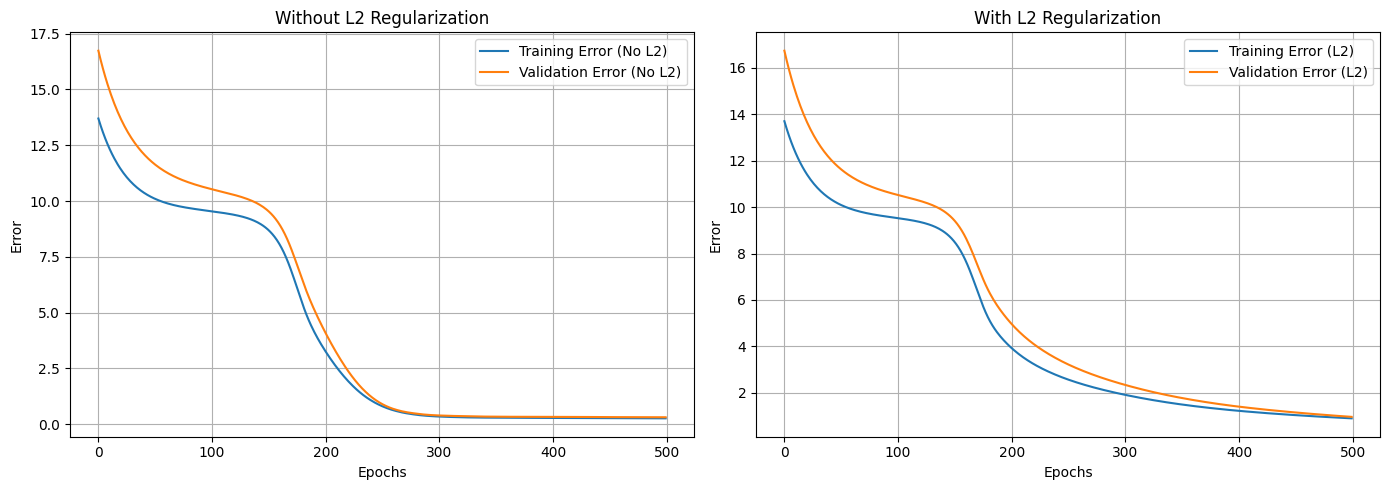

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_no_l2, label="Training Error (No L2)")
plt.plot(val_no_l2, label="Validation Error (No L2)")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Without L2 Regularization")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_l2, label="Training Error (L2)")
plt.plot(val_l2, label="Validation Error (L2)")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("With L2 Regularization")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

C:\Users\Menaka\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Menaka\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Menaka\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Menaka\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


====== WITHOUT L2 REGULARIZATION ======
Train Error : 789.1723653302465
Validation Error : 1010.408996132874
Test Error : 927.8832431643476

====== WITH L2 REGULARIZATION ======
Train Error : 790.6091319692518
Validation Error : 1009.9320844340976
Test Error : 924.9812259800653


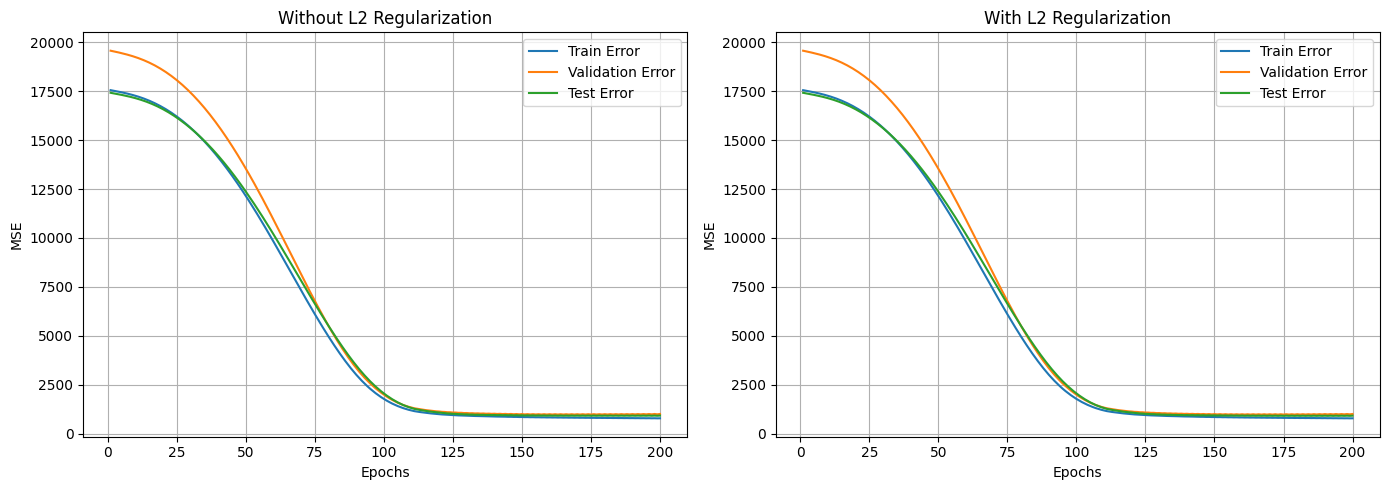

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


X, y = make_regression(
    n_samples=1000,
    n_features=10,
    noise=30,
    random_state=42
)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

epochs = 200
hidden_layers = (64, 64)

# WITHOUT L2 REGULARIZATION
model_no_l2 = MLPRegressor(
    hidden_layer_sizes=hidden_layers,
    activation='relu',
    solver='adam',
    alpha=0.0,          
    max_iter=1,
    warm_start=True,
    random_state=42
)

train_loss_no_l2 = []
val_loss_no_l2 = []
test_loss_no_l2 = []

for _ in range(epochs):
    model_no_l2.fit(X_train, y_train)

    train_pred = model_no_l2.predict(X_train)
    val_pred   = model_no_l2.predict(X_val)
    test_pred  = model_no_l2.predict(X_test)

    train_loss_no_l2.append(mean_squared_error(y_train, train_pred))
    val_loss_no_l2.append(mean_squared_error(y_val, val_pred))
    test_loss_no_l2.append(mean_squared_error(y_test, test_pred))

# WITH L2 REGULARIZATION
model_l2 = MLPRegressor(
    hidden_layer_sizes=hidden_layers,
    activation='relu',
    solver='adam',
    alpha=0.1,          
    max_iter=1,
    warm_start=True,
    random_state=42
)

train_loss_l2 = []
val_loss_l2 = []
test_loss_l2 = []

for _ in range(epochs):
    model_l2.fit(X_train, y_train)

    train_pred = model_l2.predict(X_train)
    val_pred   = model_l2.predict(X_val)
    test_pred  = model_l2.predict(X_test)

    train_loss_l2.append(mean_squared_error(y_train, train_pred))
    val_loss_l2.append(mean_squared_error(y_val, val_pred))
    test_loss_l2.append(mean_squared_error(y_test, test_pred))

print("====== WITHOUT L2 REGULARIZATION ======")
print("Train Error :", train_loss_no_l2[-1])
print("Validation Error :", val_loss_no_l2[-1])
print("Test Error :", test_loss_no_l2[-1])

print("\n====== WITH L2 REGULARIZATION ======")
print("Train Error :", train_loss_l2[-1])
print("Validation Error :", val_loss_l2[-1])
print("Test Error :", test_loss_l2[-1])

# 8. Plot Error Curves (Train + Val + Test)
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_no_l2, label="Train Error")
plt.plot(epochs_range, val_loss_no_l2, label="Validation Error")
plt.plot(epochs_range, test_loss_no_l2, label="Test Error")
plt.title("Without L2 Regularization")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss_l2, label="Train Error")
plt.plot(epochs_range, val_loss_l2, label="Validation Error")
plt.plot(epochs_range, test_loss_l2, label="Test Error")
plt.title("With L2 Regularization")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**Result:**
The L2 regularization on a sample dataset has been implemented and the error graph has been successfully ploted.